In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import random
import pickle
import os
import torch
import torch.nn as nn
from collections import Counter
from torch.utils.data import DataLoader, TensorDataset

from multitask import MultiTaskLSTM, MultiTaskTrainer
from MyRNN import myRNN
from GRU import GRURNN
from LSTM import LSTMRNN
from NQS import NameQualityMetric

In [2]:
def save_model(model, filepath):
    with open(filepath, 'wb') as f:
        pickle.dump(model, f)

def load_model(filepath):
    with open(filepath, 'rb') as f:
        model = pickle.load(f)
    return model

In [3]:
df = pd.read_csv('data/babynames-clean.csv')
df

,name,gender
0,John,boy
1,William,boy
2,James,boy
3,Charles,boy
4,George,boy
...,...,...
6777,Laylah,girl
6778,Carleigh,girl
6779,Kenley,girl
6780,Sloane,girl


Name length histogram

{2, 3, 4, 5, 6, 7, 8, 9, 10, 11}


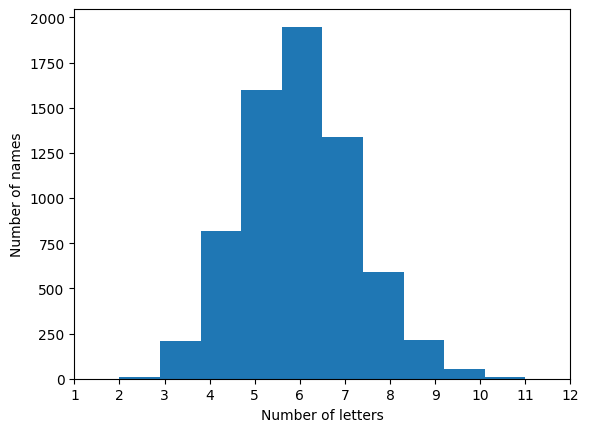

In [4]:
names_len = [len(name) for name in list(df['name'])]

print(set(names_len))

plt.hist(names_len, bins=10)
plt.xticks(np.arange(1, 13, 1))

plt.xlabel('Number of letters')
plt.ylabel('Number of names')

plt.show()

Dataset balance

In [5]:
n_girls = len(df[df['gender'] == 'girl'])
n_boys =  len(df[df['gender'] == 'boy'])
n_all = n_girls + n_boys

print(f'girls {(n_girls/n_all)*100:.1f}%, boys {(n_boys/n_all)*100:.1f}%')

girls 49.3%, boys 50.7%


Frequency of occurrence of each letter.

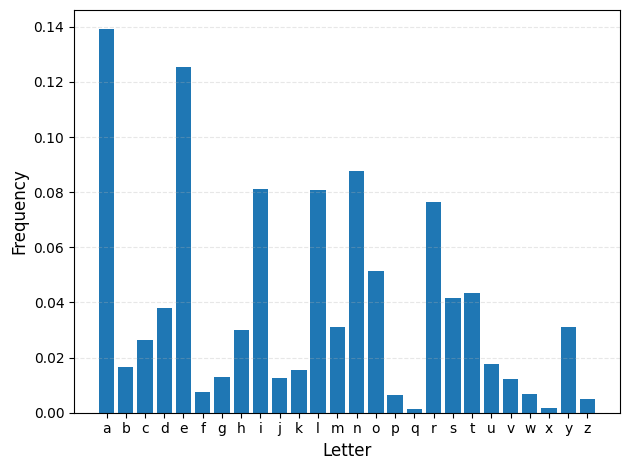

In [6]:
df['name'] = [name.lower() for name in list(df['name'])]
alphabet = 'abcdefghijklmnopqrstuvwxyz'
letter_frequencies = dict(zip(alphabet, [0 for i in range(26)]))
letter_sum = sum(names_len)

for name in list(df['name']):
    for letter in name:
        letter_frequencies[letter] += 1/letter_sum

letters = list(letter_frequencies.keys())
freqs = list(letter_frequencies.values())

plt.bar(letters, freqs)

plt.xlabel('Letter', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
df['gender'] = df['gender'].replace({'boy': 0})
df['gender'] = df['gender'].replace({'girl': 1})
df

C:\Users\HP PAVILION\AppData\Local\Temp\ipykernel_22784\3745256750.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender'] = df['gender'].replace({'girl': 1})


,name,gender
0,john,0
1,william,0
2,james,0
3,charles,0
4,george,0
...,...,...
6777,laylah,1
6778,carleigh,1
6779,kenley,1
6780,sloane,1


In [8]:
max_len = max(names_len)
for i in range(len(df)):
    name = df['name'][i]
    len_diff = max_len - len(name)
    df.loc[i, '!name#'] = '!' + name + '#' + ' '*len_diff

df

,name,gender,!name#
0,john,0,!john#
1,william,0,!william#
2,james,0,!james#
3,charles,0,!charles#
4,george,0,!george#
...,...,...,...
6777,laylah,1,!laylah#
6778,carleigh,1,!carleigh#
6779,kenley,1,!kenley#
6780,sloane,1,!sloane#


In [9]:
tokens = dict(zip(alphabet, [i for i in range(26)]))
tokens[' '] = 26
tokens['!'] = 27
tokens['#'] = 28

ids = dict(zip(tokens.values(), tokens.keys()))
ids

{0: 'a',
 1: 'b',
 2: 'c',
 3: 'd',
 4: 'e',
 5: 'f',
 6: 'g',
 7: 'h',
 8: 'i',
 9: 'j',
 10: 'k',
 11: 'l',
 12: 'm',
 13: 'n',
 14: 'o',
 15: 'p',
 16: 'q',
 17: 'r',
 18: 's',
 19: 't',
 20: 'u',
 21: 'v',
 22: 'w',
 23: 'x',
 24: 'y',
 25: 'z',
 26: ' ',
 27: '!',
 28: '#'}

In [10]:
def encode_name(name):
    name_encoded = []
    for letter in name:
        name_encoded.append(tokens[letter])
    return name_encoded

df['encoded_name'] = [encode_name(name) for name in list(df['!name#'])]
df

,name,gender,!name#,encoded_name
0,john,0,!john#,"[27, 9, 14, 7, 13, 28, 26, 26, 26, 26, 26, 26,..."
1,william,0,!william#,"[27, 22, 8, 11, 11, 8, 0, 12, 28, 26, 26, 26, 26]"
2,james,0,!james#,"[27, 9, 0, 12, 4, 18, 28, 26, 26, 26, 26, 26, 26]"
3,charles,0,!charles#,"[27, 2, 7, 0, 17, 11, 4, 18, 28, 26, 26, 26, 26]"
4,george,0,!george#,"[27, 6, 4, 14, 17, 6, 4, 28, 26, 26, 26, 26, 26]"
...,...,...,...,...
6777,laylah,1,!laylah#,"[27, 11, 0, 24, 11, 0, 7, 28, 26, 26, 26, 26, 26]"
6778,carleigh,1,!carleigh#,"[27, 2, 0, 17, 11, 4, 8, 6, 7, 28, 26, 26, 26]"
6779,kenley,1,!kenley#,"[27, 10, 4, 13, 11, 4, 24, 28, 26, 26, 26, 26,..."
6780,sloane,1,!sloane#,"[27, 18, 11, 14, 0, 13, 4, 28, 26, 26, 26, 26,..."


In [11]:
X = df['encoded_name']
y = df['gender']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, test_size=0.1, random_state=42
)

In [12]:
X_train

4047    [27, 4, 11, 11, 0, 17, 28, 26, 26, 26, 26, 26,...
6664    [27, 10, 0, 17, 8, 18, 28, 26, 26, 26, 26, 26,...
2396    [27, 1, 0, 17, 14, 13, 28, 26, 26, 26, 26, 26,...
5010      [27, 9, 0, 2, 16, 20, 4, 11, 8, 13, 28, 26, 26]
4062      [27, 9, 14, 7, 0, 13, 13, 0, 7, 28, 26, 26, 26]
                              ...                        
5099    [27, 3, 8, 0, 13, 28, 26, 26, 26, 26, 26, 26, 26]
3266    [27, 8, 18, 0, 0, 10, 28, 26, 26, 26, 26, 26, 26]
4542    [27, 12, 0, 17, 6, 17, 4, 19, 19, 28, 26, 26, 26]
3522      [27, 8, 18, 0, 1, 4, 11, 11, 0, 28, 26, 26, 26]
2531    [27, 3, 4, 21, 14, 13, 28, 26, 26, 26, 26, 26,...
Name: encoded_name, Length: 5492, dtype: object

Implementing of vanilla RNN

In [13]:
my_rnn = myRNN(vocab_size=29, hidden_dim=128)
my_rnn.fit(X_train, y_train, X_valid, y_valid, epochs=20)

Epoch   0 | Train L: 1.5082 G: 0.7150 | Val L: 1.3926 G: 0.7040
Epoch  10 | Train L: 1.2530 G: 0.6562 | Val L: 1.2920 G: 0.6794


In [14]:
def decode(name_idx):
    name = ''
    for idx in name_idx[1:-1]:
        name += ids[int(idx)]
    return name

def eval_model(model, model_name):
    model.plot_convergence()

    names = []
    for i in range(100):
        name = decode(model.generate_name())
        names.append(name)   
    print(f'Names generated by {model_name}:')
    print(*names[:10], sep=', ')

    gender_predictions = []
    for name in X_test:
        proba = model.predict_gender_for_name(name)
        if proba >= 0.5: 
            gender_predictions.append(1)
        else:
            gender_predictions.append(0)

    print(f'{model_name} gender predictions AUC score: {roc_auc_score(y_test, gender_predictions):.2f}')  
    return names  

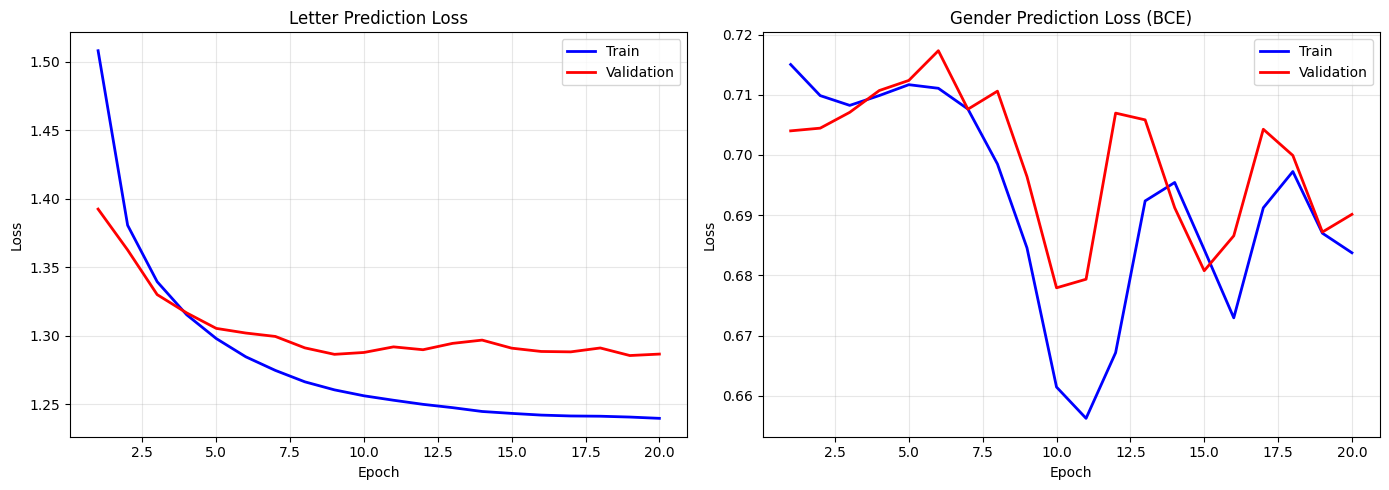

Names generated by My RNN:
grainny, salia, albin, larinard, doren, edb, mafer, fettey, sakansto, elandra
My RNN gender predictions AUC score: 0.52


In [15]:
my_rnn_names = eval_model(my_rnn, 'My RNN')

In [16]:
gru_model = GRURNN(vocab_size=29, dropout_rate=0.2)
gru_model.fit(X_train, y_train, X_valid, y_valid, epochs=20)

Epoch   0 | Train L: 1.6049, G: 0.7035 | Val L: 1.4216, G: 0.7006
Epoch   1 | Train L: 1.4150, G: 0.6907 | Val L: 1.3817, G: 0.6611
Epoch   2 | Train L: 1.3808, G: 0.6662 | Val L: 1.3473, G: 0.6143
Epoch   3 | Train L: 1.3516, G: 0.6093 | Val L: 1.3235, G: 0.5283
Epoch   4 | Train L: 1.3370, G: 0.5669 | Val L: 1.3113, G: 0.5190
Epoch   5 | Train L: 1.3234, G: 0.5508 | Val L: 1.2974, G: 0.5090
Epoch   6 | Train L: 1.3149, G: 0.5429 | Val L: 1.2906, G: 0.5059
Epoch   7 | Train L: 1.3056, G: 0.5406 | Val L: 1.2776, G: 0.4816
Epoch   8 | Train L: 1.2976, G: 0.5305 | Val L: 1.2731, G: 0.4887
Epoch   9 | Train L: 1.2898, G: 0.5244 | Val L: 1.2674, G: 0.4901
Epoch  10 | Train L: 1.2848, G: 0.5218 | Val L: 1.2584, G: 0.4939
Epoch  11 | Train L: 1.2799, G: 0.5206 | Val L: 1.2570, G: 0.4753
Epoch  12 | Train L: 1.2756, G: 0.5164 | Val L: 1.2516, G: 0.4611
Epoch  13 | Train L: 1.2733, G: 0.5117 | Val L: 1.2445, G: 0.4645
Epoch  14 | Train L: 1.2715, G: 0.5152 | Val L: 1.2448, G: 0.4570
Epoch  15 

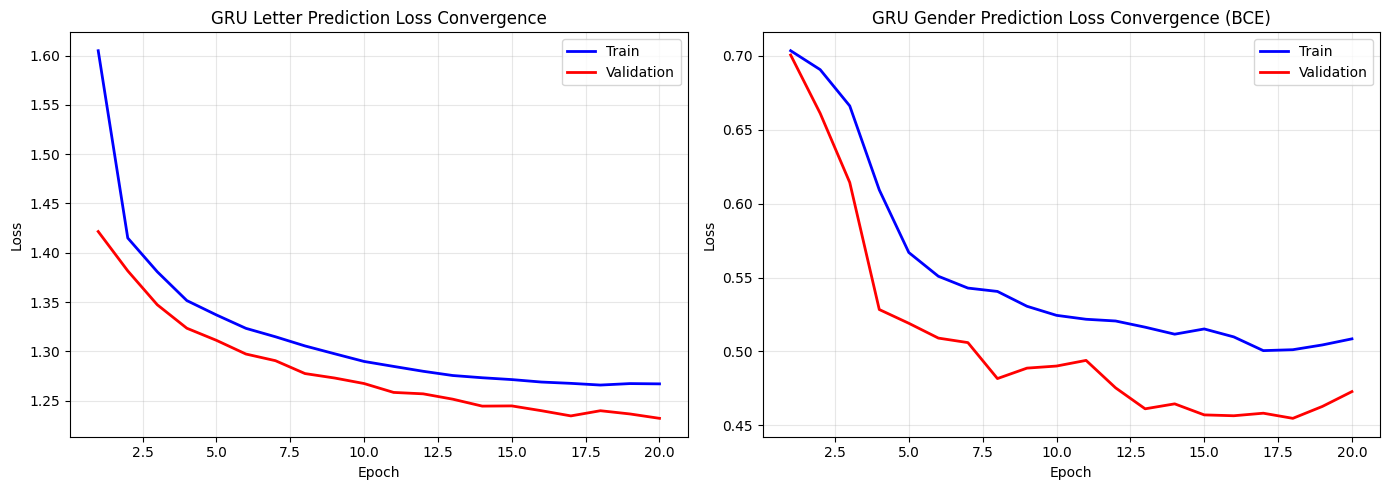

Names generated by GRU RNN:
deleth, rosanne, likat, neamesya, shamhon, horak, ren, elik, jemlild, mukia
GRU RNN gender predictions AUC score: 0.80


In [17]:
gru_names = eval_model(gru_model, 'GRU RNN')

In [18]:
lstm_model = LSTMRNN(vocab_size=29,dropout_rate=0.2)

lstm_model.fit(X_train, y_train, X_valid, y_valid, epochs=20)

Epoch   0 | Train L: 1.7396, G: 0.6963 | Val L: 1.4509, G: 0.6957
Epoch   1 | Train L: 1.4380, G: 0.6924 | Val L: 1.4037, G: 0.6919
Epoch   2 | Train L: 1.3995, G: 0.6893 | Val L: 1.3746, G: 0.6894
Epoch   3 | Train L: 1.3722, G: 0.6843 | Val L: 1.3539, G: 0.6680
Epoch   4 | Train L: 1.3509, G: 0.5917 | Val L: 1.3321, G: 0.5485
Epoch   5 | Train L: 1.3331, G: 0.5330 | Val L: 1.3120, G: 0.5006
Epoch   6 | Train L: 1.3180, G: 0.5004 | Val L: 1.2966, G: 0.4810
Epoch   7 | Train L: 1.3047, G: 0.4820 | Val L: 1.2830, G: 0.4611
Epoch   8 | Train L: 1.2929, G: 0.4679 | Val L: 1.2713, G: 0.4523
Epoch   9 | Train L: 1.2821, G: 0.4575 | Val L: 1.2620, G: 0.4522
Epoch  10 | Train L: 1.2700, G: 0.4492 | Val L: 1.2511, G: 0.4345
Epoch  11 | Train L: 1.2641, G: 0.4420 | Val L: 1.2448, G: 0.4220
Epoch  12 | Train L: 1.2563, G: 0.4395 | Val L: 1.2387, G: 0.4149
Epoch  13 | Train L: 1.2506, G: 0.4278 | Val L: 1.2329, G: 0.4208
Epoch  14 | Train L: 1.2428, G: 0.4238 | Val L: 1.2302, G: 0.4167
Epoch  15 

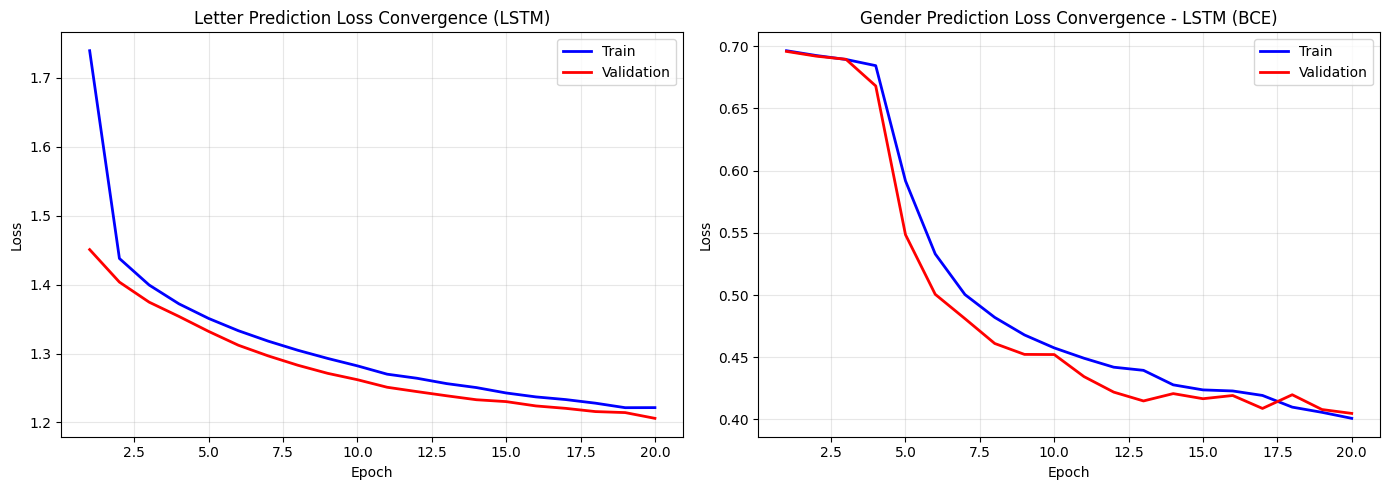

Names generated by LSTM RNN:
lylia, rissio, igros, jobani, padyll, sirw, mougan, varin, rifgena, jenort
LSTM RNN gender predictions AUC score: 0.84


In [19]:
lstm_names = eval_model(lstm_model, 'LSTM RNN')

In [20]:
save_model(my_rnn, 'models/my_rnn_model.pkl')
save_model(gru_model, 'models/gru_model.pkl')
save_model(lstm_model, 'models/lstm_model.pkl')

In [21]:
my_rnn = load_model('models/my_rnn_model.pkl')
gru_model = load_model('models/gru_model.pkl')
lstm_model = load_model('models/lstm_model.pkl')

## How to evaluate generated names quality?

Name Quality Score (NQS)

NQS = 0.4 * Fluidity + 0.3 * Plausibility + 0.2 * Diversity + 0.1 * Gender_Consistency

Or we can use perplexity metric. Perplexity measures the model's "surprise" when predicting the next character/token. 

Perplexity = exp(Cross-Entropy Loss)

In [22]:
class random_name_generator:
    def __init__(self, seed=None):
        if seed is not None:
            random.seed(seed)
        self.state = None  
        
    def reset_state(self):
        self.state = None
        
    def forward(self, x_t, training=False):
        logits = np.random.randn(27)
        return logits
    
    def softmax(self, logits):
        exp_logits = np.exp(logits - np.max(logits))
        return exp_logits / np.sum(exp_logits)
    
    def generate_name(self):
        char = 27
        name = []
        while char != 26 and len(name) < 13:
            name.append(char)
            if name == [27]:
                char = random.randint(0, 25)
            else:
                char = random.randint(0, 26)
        name.append(28)
        return decode(name)
    def generate_multiply_names(self, number):
        names = []
        for i in range(number):
            names.append(self.generate_name())
        return names

random_model = random_name_generator()

random_names = random_model.generate_multiply_names(100)

In [23]:
import random
import numpy as np

class popular_name_generator:
    def __init__(self, seed=None, top_k=3):
        if seed is not None:
            random.seed(seed)
            np.random.seed(seed)
        self.state = None     
        self.popular_letters = [[0 for i in range(29)] for i in range(29)]
        self.top_k = top_k 

    def fit(self, X):
        for name in X:
            for i in range(len(name) - 1):
                current_letter = name[i]
                next_letter = name[i+1]
                self.popular_letters[current_letter][next_letter] += 1
        for i in range(29):
            total = sum(self.popular_letters[i])
            if total > 0:
                self.popular_letters[i] = [x / total for x in self.popular_letters[i]]

    def get_top_k_indices(self, probabilities, k):
        sorted_indices = np.argsort(probabilities)[::-1]
        return sorted_indices[:k]

    def generate_name(self, max_length=15):
        char = 27 
        name = [27]
        
        while char != 28 and len(name) - 1 < max_length: 
            probs = self.popular_letters[char]
            
            top_indices = self.get_top_k_indices(probs, self.top_k)
            
            if len(name) > 1:  
                top_indices = [idx for idx in top_indices if idx != 27]
            
            top_probs = [probs[idx] for idx in top_indices]
            total_prob = sum(top_probs)
            if total_prob > 0:
                top_probs = [p / total_prob for p in top_probs]
            else:
                top_probs = [1.0 / len(top_indices)] * len(top_indices)
            
            char = np.random.choice(top_indices, p=top_probs)
            name.append(char)
        
        if name[-1] != 28:
            name.append(28)
        
        return decode(name)

    def generate_multiple_names(self, number, max_length=15):
        names = []
        for _ in range(number):
            names.append(self.generate_name(max_length))
        return names
    
    def softmax(self, logits):
        exp_logits = np.exp(logits - np.max(logits))
        return exp_logits / np.sum(exp_logits)

    def forward(self, x_t, training=False):
        if 0 <= x_t < 29:
            probs = np.array(self.popular_letters[x_t])
        else:
            probs = np.ones(29) / 29
        
        probs = probs + 1e-9
        probs = probs / np.sum(probs)
        
        logits = np.log(probs + 1e-9)
        
        self.current_char = x_t
        
        return logits
    
    def reset_state(self):
        self.current_char = 27 
        
        self.state = None

popular_model = popular_name_generator()
popular_model.fit(X_train)
popular_names = popular_model.generate_multiple_names(100)

In [24]:
nqs = NameQualityMetric(list(df['name']), gender_predictor=None)

In [25]:
def calculate_perplexity(model, X_val, rnn=False):
    total_log_prob = 0
    total_tokens = 0
    
    for word in X_val:
        model.reset_state()
        for t in range(len(word) - 1):
            x_t = word[t]
            y_next = word[t + 1]
            
            if rnn:
                logits = model.forward_rnn(x_t, training=False)
            else:
                logits = model.forward(x_t, training=False)
            probs = model.softmax(logits)
            
            log_prob = np.log(probs[y_next] + 1e-9)
            total_log_prob += log_prob
            total_tokens += 1
    
    avg_log_prob = total_log_prob / total_tokens
    perplexity = np.exp(-avg_log_prob)
    
    return perplexity

In [26]:
score, components = nqs.compute(random_names)

nqs.detailed_report(random_names, "Random Model")

val_perplexity = calculate_perplexity(my_rnn, X_valid, rnn=True)
print(f"Validation Perplexity: {val_perplexity:.2f}")

Name Quality Score - Random Model
Total Score: 0.363 / 1.000

Component Scores:
  Fluidity:       0.127 (weight: 0.4)
  Plausibility: 0.207 (weight: 0.3)
  Diversity:   1.000 (weight: 0.2)
  Gender Consistency:    0.500 (weight: 0.1)
Validation Perplexity: 3.62


In [27]:
score, components = nqs.compute(popular_names)

nqs.detailed_report(popular_names, "Random Model")

val_perplexity = calculate_perplexity(popular_model, X_valid)
print(f"Validation Perplexity: {val_perplexity:.2f}")

Name Quality Score - Random Model
Total Score: 0.371 / 1.000

Component Scores:
  Fluidity:       0.308 (weight: 0.4)
  Plausibility: 0.307 (weight: 0.3)
  Diversity:   0.530 (weight: 0.2)
  Gender Consistency:    0.500 (weight: 0.1)
Validation Perplexity: 4.01


In [28]:
score, components = nqs.compute(my_rnn_names)

nqs.detailed_report(my_rnn_names, "My RNN Model")

val_perplexity = calculate_perplexity(my_rnn, X_valid, rnn=True)
print(f"Validation Perplexity: {val_perplexity:.2f}")

Name Quality Score - My RNN Model
Total Score: 0.449 / 1.000

Component Scores:
  Fluidity:       0.369 (weight: 0.4)
  Plausibility: 0.277 (weight: 0.3)
  Diversity:   0.843 (weight: 0.2)
  Gender Consistency:    0.500 (weight: 0.1)
Validation Perplexity: 3.62


In [29]:
score, components = nqs.compute(gru_names)

nqs.detailed_report(gru_names, "GRU RNN Model")

val_perplexity = calculate_perplexity(gru_model, X_valid)
print(f"Validation Perplexity: {val_perplexity:.2f}")

Name Quality Score - GRU RNN Model
Total Score: 0.450 / 1.000

Component Scores:
  Fluidity:       0.390 (weight: 0.4)
  Plausibility: 0.280 (weight: 0.3)
  Diversity:   0.801 (weight: 0.2)
  Gender Consistency:    0.500 (weight: 0.1)
Validation Perplexity: 3.43


In [30]:
score, components = nqs.compute(lstm_names)

nqs.detailed_report(lstm_names, "LSTM RNN Model")

val_perplexity = calculate_perplexity(lstm_model, X_valid)
print(f"Validation Perplexity: {val_perplexity:.2f}")

Name Quality Score - LSTM RNN Model
Total Score: 0.449 / 1.000

Component Scores:
  Fluidity:       0.405 (weight: 0.4)
  Plausibility: 0.285 (weight: 0.3)
  Diversity:   0.759 (weight: 0.2)
  Gender Consistency:    0.500 (weight: 0.1)
Validation Perplexity: 3.34


Let's train RNN, GRU, and LSTM, but with a different loss function

In [31]:
model_nll = myRNN(vocab_size=29, gender_loss='nll')
model_nll.fit(X_train, y_train, X_valid, y_valid, epochs=20)

Epoch   0 | Train L: 1.5131 G: 0.7066 | Val L: 1.3919 G: 0.7051
Epoch  10 | Train L: 1.2422 G: 0.6958 | Val L: 1.2815 G: 0.7057


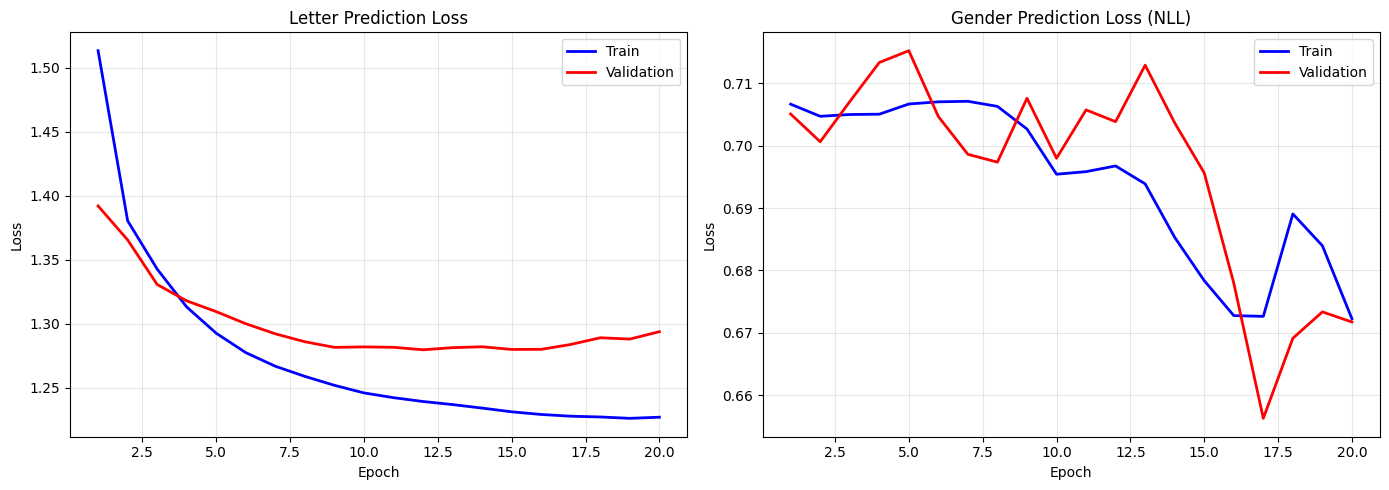

Names generated by My RNN with nll:
lie, irand, odamika, daanna, liava, eanza, almerie, litha, leardeliletton, ivon
My RNN with nll gender predictions AUC score: 0.55


In [32]:
rnn_nll_names = eval_model(model_nll, 'My RNN with nll')

In [33]:
gru_nll = GRURNN(
    vocab_size=29,
    hidden_dim=128,
    embedding_dim=64,
    learning_rate=0.01,
    dropout_rate=0.2,
    gender_loss_type='nll'
)
gru_nll.fit(X_train, y_train, X_valid, y_valid, epochs=20, verbose=True)

Epoch   0 | Train L: 1.6049, G: 0.7035 | Val L: 1.4216, G: 0.7006
Epoch   1 | Train L: 1.4150, G: 0.6907 | Val L: 1.3817, G: 0.6611
Epoch   2 | Train L: 1.3808, G: 0.6662 | Val L: 1.3473, G: 0.6143
Epoch   3 | Train L: 1.3516, G: 0.6093 | Val L: 1.3235, G: 0.5283
Epoch   4 | Train L: 1.3370, G: 0.5669 | Val L: 1.3113, G: 0.5190
Epoch   5 | Train L: 1.3234, G: 0.5508 | Val L: 1.2974, G: 0.5090
Epoch   6 | Train L: 1.3149, G: 0.5429 | Val L: 1.2906, G: 0.5059
Epoch   7 | Train L: 1.3056, G: 0.5406 | Val L: 1.2776, G: 0.4816
Epoch   8 | Train L: 1.2976, G: 0.5305 | Val L: 1.2731, G: 0.4887
Epoch   9 | Train L: 1.2898, G: 0.5244 | Val L: 1.2674, G: 0.4901
Epoch  10 | Train L: 1.2848, G: 0.5218 | Val L: 1.2584, G: 0.4939
Epoch  11 | Train L: 1.2799, G: 0.5206 | Val L: 1.2570, G: 0.4753
Epoch  12 | Train L: 1.2756, G: 0.5164 | Val L: 1.2516, G: 0.4611
Epoch  13 | Train L: 1.2733, G: 0.5117 | Val L: 1.2445, G: 0.4645
Epoch  14 | Train L: 1.2715, G: 0.5152 | Val L: 1.2448, G: 0.4570
Epoch  15 

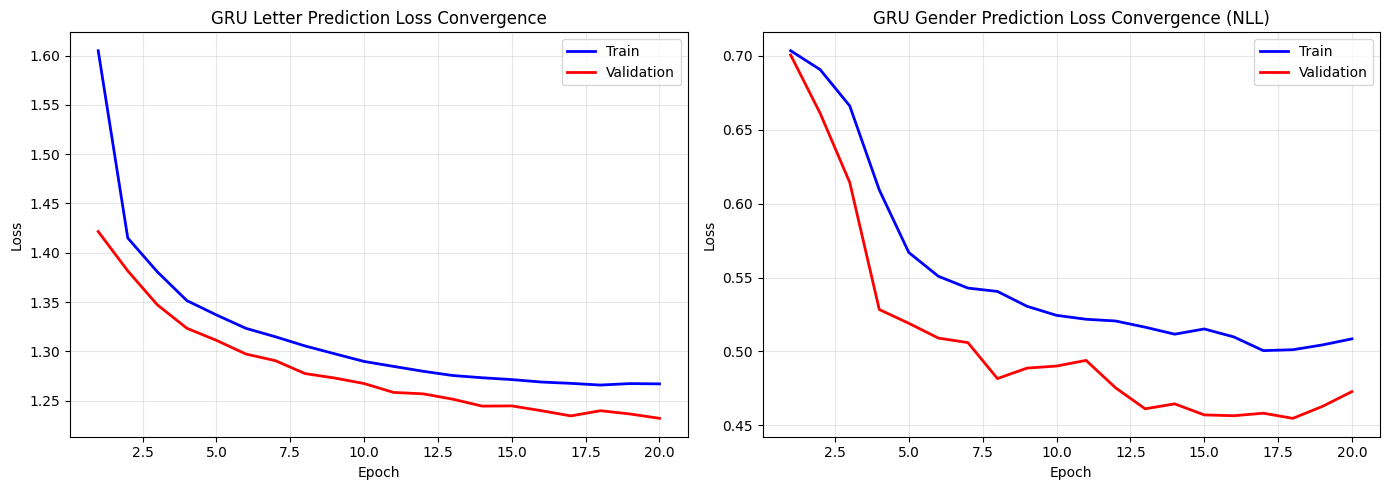

Names generated by GRU with nll:
deleth, rosanne, likat, neamesya, shamhon, horak, ren, elik, jemlild, mukia
GRU with nll gender predictions AUC score: 0.80


In [34]:
gru_nll_names = eval_model(gru_nll, 'GRU with nll')

In [35]:
lstm_nll = LSTMRNN(
    vocab_size=29,
    hidden_dim=128,
    embedding_dim=64,
    learning_rate=0.01,
    dropout_rate=0.2,
    gender_loss_type='nll'
)
lstm_nll.fit(X_train, y_train, X_valid, y_valid, epochs=20, verbose=True)

Epoch   0 | Train L: 1.7396, G: 0.6963 | Val L: 1.4509, G: 0.6957
Epoch   1 | Train L: 1.4380, G: 0.6924 | Val L: 1.4037, G: 0.6919
Epoch   2 | Train L: 1.3995, G: 0.6893 | Val L: 1.3746, G: 0.6894
Epoch   3 | Train L: 1.3722, G: 0.6843 | Val L: 1.3539, G: 0.6680
Epoch   4 | Train L: 1.3509, G: 0.5917 | Val L: 1.3321, G: 0.5485
Epoch   5 | Train L: 1.3331, G: 0.5330 | Val L: 1.3120, G: 0.5006
Epoch   6 | Train L: 1.3180, G: 0.5004 | Val L: 1.2966, G: 0.4810
Epoch   7 | Train L: 1.3047, G: 0.4820 | Val L: 1.2830, G: 0.4611
Epoch   8 | Train L: 1.2929, G: 0.4679 | Val L: 1.2713, G: 0.4523
Epoch   9 | Train L: 1.2821, G: 0.4575 | Val L: 1.2620, G: 0.4522
Epoch  10 | Train L: 1.2700, G: 0.4492 | Val L: 1.2511, G: 0.4345
Epoch  11 | Train L: 1.2641, G: 0.4420 | Val L: 1.2448, G: 0.4220
Epoch  12 | Train L: 1.2563, G: 0.4395 | Val L: 1.2387, G: 0.4149
Epoch  13 | Train L: 1.2506, G: 0.4278 | Val L: 1.2329, G: 0.4208
Epoch  14 | Train L: 1.2428, G: 0.4238 | Val L: 1.2302, G: 0.4167
Epoch  15 

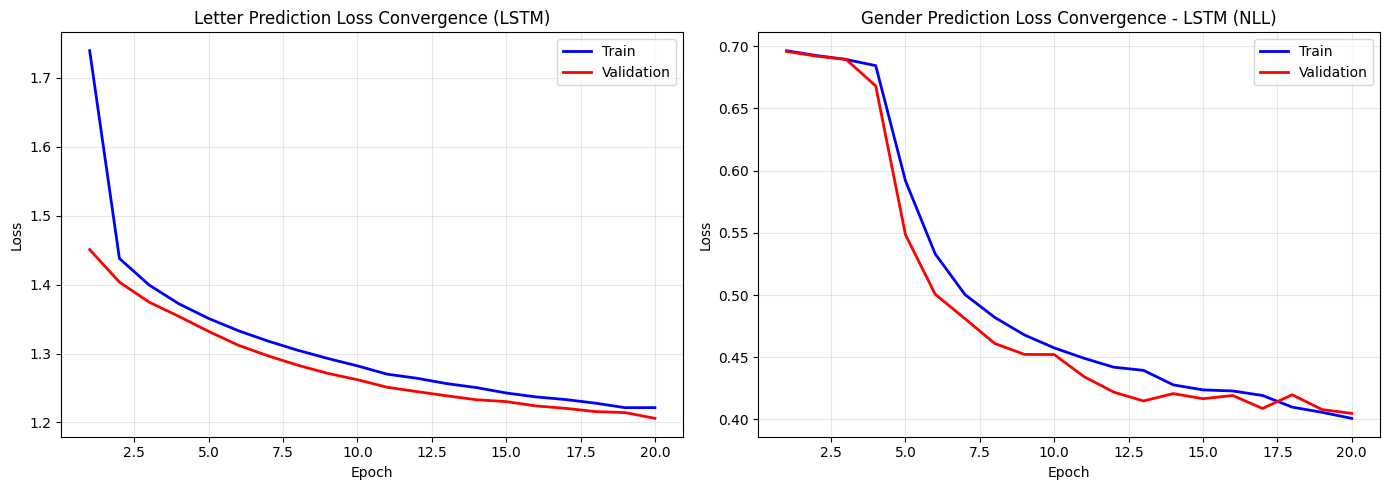

Names generated by LSTM with nll:
lylia, rissio, igros, jobani, padyll, sirw, mougan, varin, rifgena, jenort
LSTM with nll gender predictions AUC score: 0.84


In [36]:
lstm_nll_names = eval_model(lstm_nll, 'LSTM with nll')

In [37]:
save_model(model_nll, 'models/my_rnn_nll.pkl')
save_model(gru_nll, 'models/gru_nll.nll')
save_model(lstm_nll, 'models/lstm_nll.pkl')

## Vanishing Gradient

Taking a subset of the training dataset where name lengths equal their mode is essential for studying gradient vanishing because it eliminates the confounding variable of sequence length variability, allowing for controlled and systematic observation of how gradients decay solely as a function of time steps. With fixed-length sequences, we can reliably compute and compare gradient norms across identical propagation depths, diagnose the rate of gradient decay, and fairly evaluate different RNN architectures (vanilla RNN vs. LSTM vs. GRU) without the noise introduced by varying input lengths, which would otherwise obscure the pure effect of the vanishing gradient problem.

In [13]:
def get_real_length(seq):
    return sum(1 for t in seq if t != 26)

lengths = [get_real_length(seq) for seq in X_train]
mode_len = Counter(lengths).most_common(1)[0][0]

X_mode = [seq for seq in X_train if get_real_length(seq) == mode_len]
y_mode = [y for seq, y in zip(X_train, y_train) if get_real_length(seq) == mode_len]

X_tensor = torch.tensor(X_mode, dtype=torch.long)
y_tensor = torch.tensor(y_mode, dtype=torch.float32).view(-1, 1)

print(f"mode: {mode_len}")

mode: 8


In [14]:
class SimpleRNN(nn.Module):
    def __init__(self, vocab_size=29, embed_dim=8, hidden_dim=16):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=26)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        e = self.embed(x)
        out, _ = self.rnn(e)
        last = out[:, -1, :]
        return torch.sigmoid(self.fc(last))

model = SimpleRNN()
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
n_epochs = 1
batch_size = 1
max_name_length = X_tensor.shape[1]
n_tokens = 29
embedding_size = 8

gradient_tensor = torch.zeros(n_epochs, max_name_length, n_tokens, embedding_size)

current_name_idx = 0

current_name_idx = 0

def hook_fn(module, grad_input, grad_output):
    grad = grad_output[0]
    
    for pos in range(grad.shape[1]):
        if pos < max_name_length:
            token_idx = X_tensor[current_name_idx, pos].item()
            gradient_tensor[0, pos, token_idx, :] = grad[0, pos, :]

hook = model.embed.register_backward_hook(hook_fn)

In [15]:
for name_idx, (seq, label) in enumerate(zip(X_tensor, y_tensor)):
    current_name_idx = name_idx  
    
    seq = seq.unsqueeze(0) 
    label = label.unsqueeze(0) 
    
    optimizer.zero_grad()
    pred = model(seq)
    loss = criterion(pred, label)
    loss.backward()
    optimizer.step()

hook.remove()

C:\Users\HP PAVILION\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\module.py:1842: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


In [16]:
norm_tensor = torch.norm(gradient_tensor, dim=-1)
print(f"norm_tensor shape: {norm_tensor.shape}")

norm_tensor shape: torch.Size([1, 13, 29])


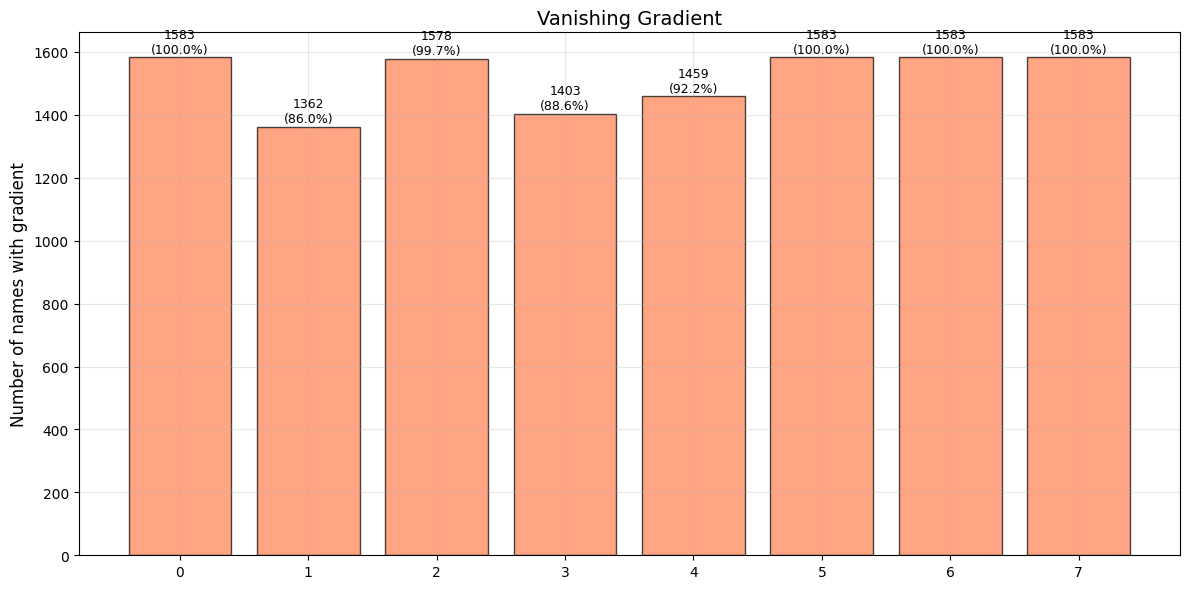

In [17]:
n_names = X_tensor.shape[0]
gradient_matrix = np.zeros((n_names, mode_len))

for name_idx in range(n_names):
    seq = X_tensor[name_idx].tolist()
    real_seq = [t for t in seq if t != 26]
    
    name_norm = norm_tensor[0, :mode_len, :]
    nonzero_mask = name_norm > 1e-6
    nonzero_positions = torch.nonzero(nonzero_mask)
    
    for pos, token in nonzero_positions:
        pos_idx = pos.item()
        token_idx = token.item()
        if pos_idx < len(real_seq) and real_seq[pos_idx] == token_idx:
            gradient_matrix[name_idx, pos_idx] = 1

fig, ax = plt.subplots(figsize=(12, 6))

gradient_count = np.sum(gradient_matrix, axis=0)
gradient_percent = (gradient_count / n_names) * 100

positions = range(mode_len)

bars = ax.bar(positions, gradient_count, color='coral', alpha=0.7, edgecolor='black')

ax.set_ylabel('Number of names with gradient', fontsize=12)
ax.set_title(f'Vanishing Gradient', fontsize=14)
ax.set_xticks(positions)
ax.set_xticklabels([f"{i}" for i in range(mode_len)])
ax.grid(True, alpha=0.3)

for i, (count, percent) in enumerate(zip(gradient_count, gradient_percent)):
    if count > 0:
        ax.text(i, count + 5, f'{int(count)}\n({percent:.1f}%)', 
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [18]:
def frobenius_norm(grad_tensor):
    n_epochs, max_len, _, _ = grad_tensor.shape
    result = torch.zeros(n_epochs, max_len)
    
    for epoch in range(n_epochs):
        for pos in range(max_len):
            matrix = grad_tensor[epoch, pos, :, :]
            result[epoch, pos] = torch.norm(matrix, p='fro')
    
    return result

frob = frobenius_norm(gradient_tensor)
frob.shape

torch.Size([1, 13])

In [19]:
def mean_over_epochs(frob_norm):
    return torch.mean(frob_norm, dim=0)
    
mean_over_epochs(frob)

tensor([1.2536e-06, 1.6697e-01, 1.4999e-01, 1.1030e+00, 9.1650e-02, 1.2545e+00,
        3.1605e+00, 9.0440e-04, 1.5237e-03, 1.1557e-02, 9.5391e-03, 7.5993e-02,
        2.6625e-02])

In [20]:
def create_model(model_type, vocab_size=29, embed_dim=8, hidden_dim=16):
    class Model(nn.Module):
        def __init__(self):
            super().__init__()
            self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=26)
            if model_type == 'rnn':
                self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
            elif model_type == 'lstm':
                self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
            elif model_type == 'gru':
                self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)
            self.fc = nn.Linear(hidden_dim, 1)
        
        def forward(self, x):
            e = self.embed(x)
            out, _ = self.rnn(e)
            return torch.sigmoid(self.fc(out[:, -1, :]))
    return Model()

In [21]:
def collect_gradients(model, X_data, y_data, n_epochs=1):
    max_len = X_data.shape[1]
    n_tokens = 29
    embed_dim = 8
    
    grad_tensor = torch.zeros(n_epochs, max_len, n_tokens, embed_dim)
    
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    
    for epoch in range(n_epochs):
        model.zero_grad()
        
        for idx, (seq, label) in enumerate(zip(X_data, y_data)):
            seq = seq.unsqueeze(0)  # (1, seq_len)
            label = label.unsqueeze(0)  # (1, 1)
            
            optimizer.zero_grad()
            pred = model(seq)
            loss = criterion(pred, label)
            
            loss.backward()
            
            emb_grad = model.embed.weight.grad  # (29, 8)
            
            for pos in range(seq.size(1)):
                token = seq[0, pos].item()  
                grad_tensor[epoch, pos, token, :] = emb_grad[token, :]
            
            optimizer.step()
    
    return grad_tensor

In [ ]:
models = ['rnn', 'gru', 'lstm']
results = {}
    
for model_type in models:
    print(f"Training {model_type.upper()}...")
    model = create_model(model_type)
    grad_tensor = collect_gradients(model, X_tensor, y_tensor, n_epochs=10)
    frob = frobenius_norm(grad_tensor)
    mean_norm = mean_over_epochs(frob)
    results[model_type] = mean_norm.numpy()
    
plt.figure(figsize=(10, 6))
for model_type, data in results.items():
    plt.plot(range(len(data)), data, marker='o', label=model_type.upper())
    
plt.xlabel('Position in name (from start)')
plt.ylabel('Mean Frobenius Norm of Gradient')
plt.title('Gender Classification Task')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Training RNN...
Training GRU...
Training LSTM...


Repeat steps b-f when training the model for the next letter prediction task. What is the difference?

In [ ]:
X_data = []
y_data = []

PAD_IDX = 26 
VOCAB_SIZE = 29
EMBED_DIM = 8
HIDDEN_DIM = 16
N_EPOCHS = 5

for seq in X_mode:
    seq_no_pad = [t for t in seq if t != PAD_IDX]  
    for i in range(len(seq_no_pad) - 1):
        X_data.append(seq_no_pad[:i+1])   
        y_data.append(seq_no_pad[i+1])     

max_len = max(len(s) for s in X_data)
X_padded = [s + [PAD_IDX] * (max_len - len(s)) for s in X_data]  
X_tensor = torch.tensor(X_padded, dtype=torch.long)
y_tensor = torch.tensor(y_data, dtype=torch.long)

In [ ]:
def create_model(model_type):
    class NextLetterModel(nn.Module):
        def __init__(self):
            super().__init__()
            self.embed = nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=PAD_IDX)
            if model_type == 'rnn':
                self.rnn = nn.RNN(EMBED_DIM, HIDDEN_DIM, batch_first=True, nonlinearity='tanh')
            elif model_type == 'lstm':
                self.rnn = nn.LSTM(EMBED_DIM, HIDDEN_DIM, batch_first=True)
            elif model_type == 'gru':
                self.rnn = nn.GRU(EMBED_DIM, HIDDEN_DIM, batch_first=True)
            else:
                raise ValueError("Unknown model type")
            self.fc = nn.Linear(HIDDEN_DIM, VOCAB_SIZE)

            for name, param in self.rnn.named_parameters():
                if 'weight_ih' in name:
                    nn.init.xavier_uniform_(param)
                elif 'weight_hh' in name:
                    nn.init.orthogonal_(param)
                elif 'bias' in name:
                    nn.init.zeros_(param)
            nn.init.xavier_uniform_(self.fc.weight)
            nn.init.zeros_(self.fc.bias)

        def forward(self, x):
            e = self.embed(x)        
            out, _ = self.rnn(e)     
            last = out[:, -1, :]       
            return self.fc(last)       

    return NextLetterModel()

In [ ]:
def collect_gradients(model_type, X_data, y_data, n_epochs=N_EPOCHS):
    model = create_model(model_type)
    model.train()

    grad_tensor = torch.zeros(n_epochs, max_len, VOCAB_SIZE, EMBED_DIM)

    current_epoch = 0
    current_sample_idx = 0

    def hook_fn(module, grad_input, grad_output):
        grad = grad_output[0] 
        for pos in range(grad.size(1)):
            if pos < max_len:
                token = X_data[current_sample_idx, pos].item()
                grad_tensor[current_epoch, pos, token, :] = grad[0, pos, :]

    hook = model.embed.register_backward_hook(hook_fn)

    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

    for epoch in range(n_epochs):
        current_epoch = epoch
        for idx, (seq, target) in enumerate(zip(X_data, y_data)):
            current_sample_idx = idx
            seq = seq.unsqueeze(0)  
            target = target.unsqueeze(0) 

            optimizer.zero_grad()
            logits = model(seq)      
            loss = criterion(logits, target)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

    hook.remove()
    return grad_tensor

X_tensor shape: torch.Size([11081, 7]), y_tensor shape: torch.Size([11081])
Training RNN...


C:\Users\HP PAVILION\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\module.py:1842: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Training GRU...
Training LSTM...


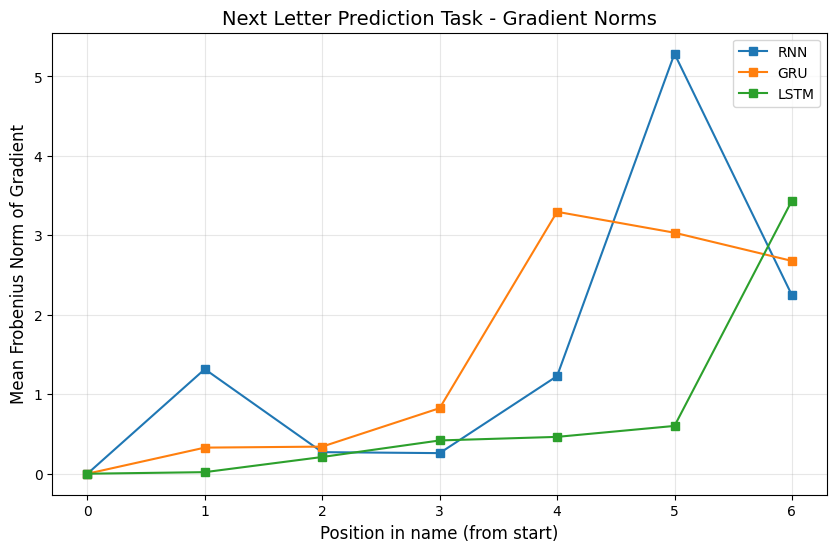

In [ ]:
models = ['rnn', 'gru', 'lstm']
results = {}

for model_type in models:
    print(f"Training {model_type.upper()}...")
    grad_tensor = collect_gradients(model_type, X_tensor, y_tensor)

    frob_norms = []
    for pos in range(max_len):
        pos_data = grad_tensor[:, pos, :, :] 
        norms_per_epoch = torch.norm(pos_data, dim=(1,2)) 
        mean_norm = norms_per_epoch.mean().item()
        frob_norms.append(mean_norm)

    results[model_type] = np.array(frob_norms)

plt.figure(figsize=(10, 6))
for model_type, data in results.items():
    plt.plot(range(len(data)), data, marker='s', label=model_type.upper())

plt.xlabel('Position in name (from start)', fontsize=12)
plt.ylabel('Mean Frobenius Norm of Gradient', fontsize=12)
plt.title('Next Letter Prediction Task - Gradient Norms', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In gender classification, where the output is produced only at the final time step (the last character of the name), the loss is computed solely for the final character, causing the error signal to backpropagate through the entire sequence in a single pass — from the last character all the way to the first. This forces gradients to traverse the maximum number of transformations, resulting in stronger and faster gradient vanishing during backpropagation through time (BPTT). In contrast, in next-character prediction (character-level language modeling), the loss is computed at every time step — each character predicts the following one — which creates a denser gradient flow, allows gradients to be updated locally at each step, and makes the vanishing effect more uniform and less severe, as gradients do not have to propagate through the full sequence length in a single backward pass.

### Multitask Learning

In [ ]:
def prepare_sequences(names_encoded, gender_labels):
    if isinstance(names_encoded, pd.Series):
        names_encoded = names_encoded.tolist()
    if isinstance(gender_labels, pd.Series):
        gender_labels = gender_labels.tolist()
    
    names_encoded = [list(name) if not isinstance(name, list) else name 
                     for name in names_encoded]
    
    sequences = torch.tensor(names_encoded, dtype=torch.long)
    
    targets = sequences[:, 1:]
    
    targets_genders = torch.tensor(gender_labels, dtype=torch.float32)
    
    return sequences, targets, targets_genders

In [ ]:
if isinstance(X_train, pd.Series):
        X_train = X_train.tolist()
if isinstance(X_valid, pd.Series):
        X_valid = X_valid.tolist()
    
X_train = [list(x) if not isinstance(x, list) else x for x in X_train]
X_valid = [list(x) if not isinstance(x, list) else x for x in X_valid]
    
X_train_tensor, y_train_tensor, gender_train_tensor = prepare_sequences(X_train, y_train)
X_val_tensor, y_val_tensor, gender_val_tensor = prepare_sequences(X_valid, y_valid)
    
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor, gender_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor, gender_val_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
model = MultiTaskLSTM(
        vocab_size=29,
        hidden_dim=64,
        embedding_dim=32,
        num_layers=1,
        dropout_rate=0.3
    )
    
total_params = sum(p.numel() for p in model.parameters())

trainer = MultiTaskTrainer(model)
trainer.fit(
        train_loader, val_loader, 
        epochs=100, lr=0.001,
        gender_weight=0.3, 
        early_stopping_patience=10
    )

Эпоха   0 | Train L: 2.8768, G: 0.6868 | Val L: 2.6014, G: 0.6629 | LR: 0.001000
Эпоха  10 | Train L: 2.1843, G: 0.4349 | Val L: 2.1794, G: 0.4208 | LR: 0.001000
Эпоха  20 | Train L: 2.1063, G: 0.4065 | Val L: 2.1282, G: 0.4220 | LR: 0.001000
Эпоха  30 | Train L: 2.0616, G: 0.3875 | Val L: 2.0906, G: 0.3919 | LR: 0.001000
Эпоха  40 | Train L: 2.0304, G: 0.3571 | Val L: 2.0712, G: 0.3851 | LR: 0.001000
Эпоха  50 | Train L: 2.0083, G: 0.3389 | Val L: 2.0547, G: 0.3585 | LR: 0.001000
Эпоха  60 | Train L: 1.9888, G: 0.3214 | Val L: 2.0422, G: 0.3695 | LR: 0.001000
Эпоха  70 | Train L: 1.9736, G: 0.3082 | Val L: 2.0420, G: 0.3676 | LR: 0.001000
Эпоха  80 | Train L: 1.9618, G: 0.2941 | Val L: 2.0331, G: 0.3624 | LR: 0.001000
Эпоха  90 | Train L: 1.9481, G: 0.2714 | Val L: 2.0279, G: 0.3687 | LR: 0.000500

Ранняя остановка на эпохе 95


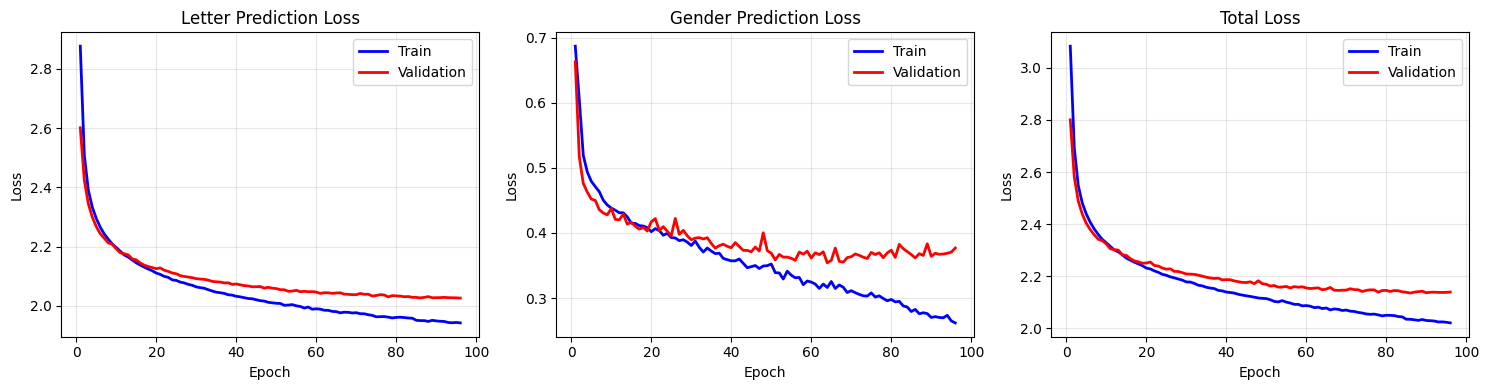

In [ ]:
trainer.plot_convergence()

In [ ]:
predicted_names = []
for i in range(10):
    predicted_names.append(trainer.generate_name(temperature=1.0))
predicted_names

['jacers',
 'roanna',
 'hooy',
 'elten',
 'sabella',
 'codi',
 'esdia',
 'rolber',
 'rocell',
 'leon']

In [ ]:
all_preds = []
all_labels = []
for name_encoded, gender in zip(X_test, y_test):
    prob = trainer.predict_gender(name_encoded)
    all_preds.append(prob)
    all_labels.append(gender)
    
auc_score = roc_auc_score(all_labels, all_preds)

print(f"AUC ROC on test: {auc_score:.4f}")

AUC ROC on test: 0.9388


### Visualizing embeddings

In [ ]:
def visualize_embeddings(embeddings, idx_to_char, title_prefix=""):
    char_list = [idx_to_char[i] for i in range(len(idx_to_char))]
    vowels = set('aeiou')

    methods = {
        't-SNE': TSNE(n_components=2, random_state=21, perplexity=15),
        'PCA': PCA(n_components=2, random_state=21)
    }
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    for ax, (method_name, method) in zip(axes, methods.items()):
        embeddings_2d = method.fit_transform(embeddings)
        
        for i, (char, pos) in enumerate(zip(char_list, embeddings_2d)):
            is_vowel = char in vowels
            color = 'red' if is_vowel else 'blue'
            marker = 'o' if is_vowel else 's'
            ax.scatter(pos[0], pos[1], c=color, marker=marker, s=100, alpha=0.7)
            ax.annotate(char, (pos[0], pos[1]), fontsize=12, fontweight='bold')
        
        ax.set_title(f'{title_prefix}{method_name} Visualization')
        ax.set_xlabel('Component 1')
        ax.set_ylabel('Component 2')
        ax.grid(True, alpha=0.3)
        
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='red', alpha=0.7, label='Vowels'),
            Patch(facecolor='blue', alpha=0.7, label='Consonants')
        ]
        ax.legend(handles=legend_elements)
    
    plt.tight_layout()
    plt.show()

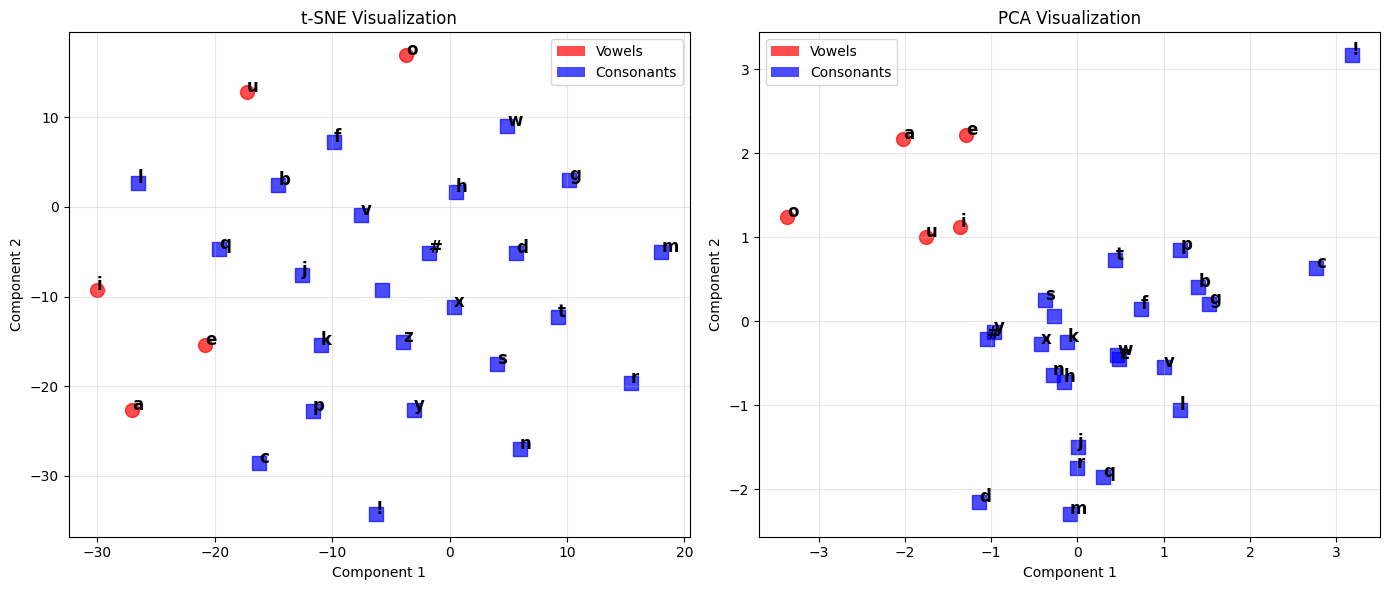

In [ ]:
embeddings = trainer.get_embeddings()
visualize_embeddings(embeddings, ids)

In [ ]:
save_model(trainer, 'models/best_model.pkl')

In [ ]:
model = load_model('models/best_model.pkl')

In [ ]:
name = 'benjamin'
len_diff = max_len - len(name)
name = '!' + name + '#' + ' '*len_diff
name = encode_name(name)

np.round(model.predict_gender(name))

C:\Users\HP PAVILION\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:1124: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1481.)
  result = _VF.lstm(


np.float64(0.0)

In [ ]:
gender_predictions = []
names_decoded = []
for name in X_test:
    gender_predictions.append(np.round(model.predict_gender(name)))
    names_decoded.append(decode(name))

df = pd.DataFrame({
    'name': names_decoded,
    'gender_prediction': gender_predictions
})
df.to_csv('test_predictions.csv', index=False)

C:\Users\HP PAVILION\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\rnn.py:1124: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1481.)
  result = _VF.lstm(
